[Font] 已检测到中文字体: SimHei
步骤1：单一噪声水平的困境


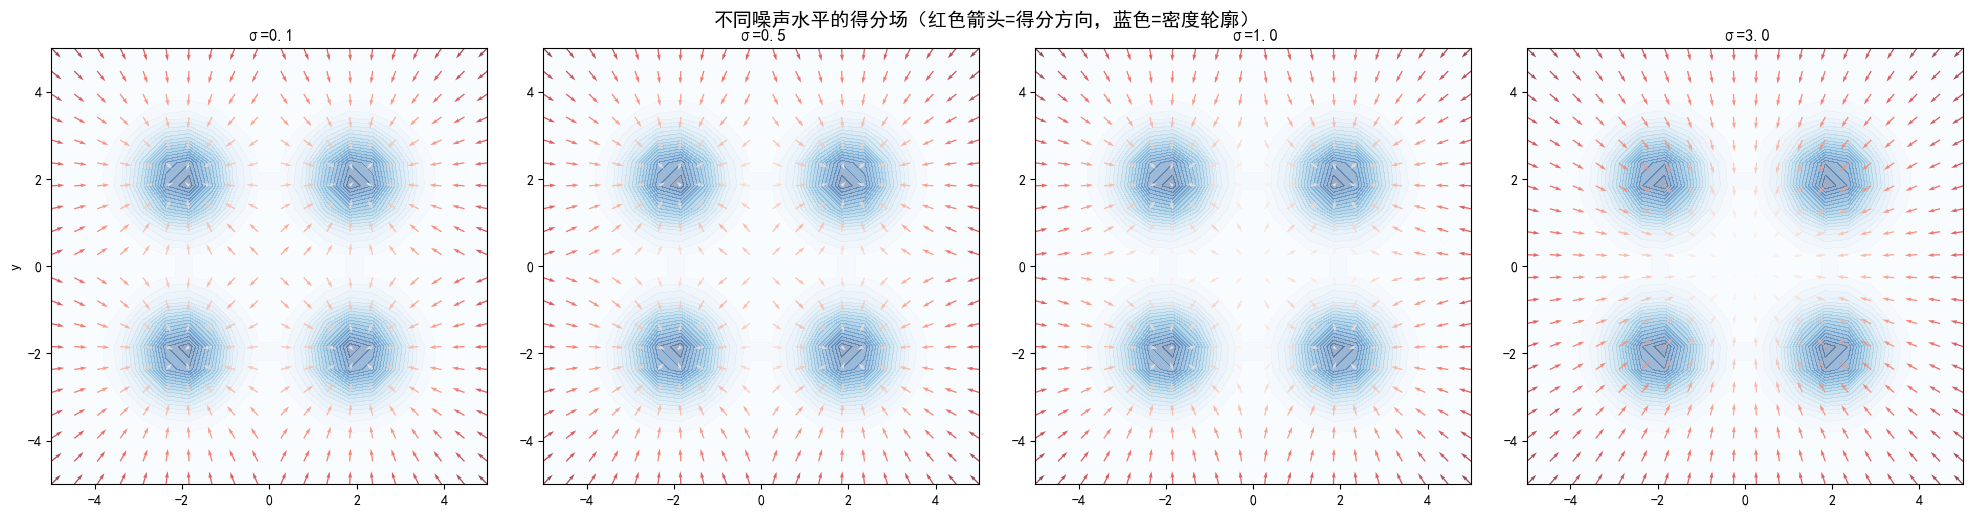

观察：
  σ=0.1: 得分仅在模态附近非零，模态之间（低密度区域）几乎无方向指引
  σ=0.5: 得分开始覆盖模态间区域
  σ=1.0: 得分在整个区域都有方向指引，但模态细节开始模糊
  σ=3.0: 得分全局覆盖良好，但无法区分不同模态——'只见森林不见树木'

步骤2：NCSN多噪声水平训练
噪声调度 (L=5): σ = ['3.000', '1.282', '0.548', '0.234', '0.100']
几何级数公比 r = 2.340

训练NCSN (5个噪声水平)...
  Epoch 200: NCSN loss = 0.794347
  Epoch 400: NCSN loss = 0.782338
  Epoch 600: NCSN loss = 0.765626
  Epoch 800: NCSN loss = 0.722500
  Epoch 1000: NCSN loss = 0.715578
NCSN训练完成！

步骤3：退火Langevin vs 单噪声Langevin采样对比

运行单噪声Langevin (σ=0.10, T=500)...
运行退火Langevin (L=5, T_per_level=100)...

各象限样本比例:
    象限 |       真实 |     单噪声ULA |    退火ULA
------------------------------------------
Q1(++) |    0.228 |      0.259 |    0.231
Q2(-+) |    0.272 |      0.291 |    0.248
Q3(--) |    0.244 |      0.263 |    0.264
Q4(+-) |    0.256 |      0.187 |    0.257


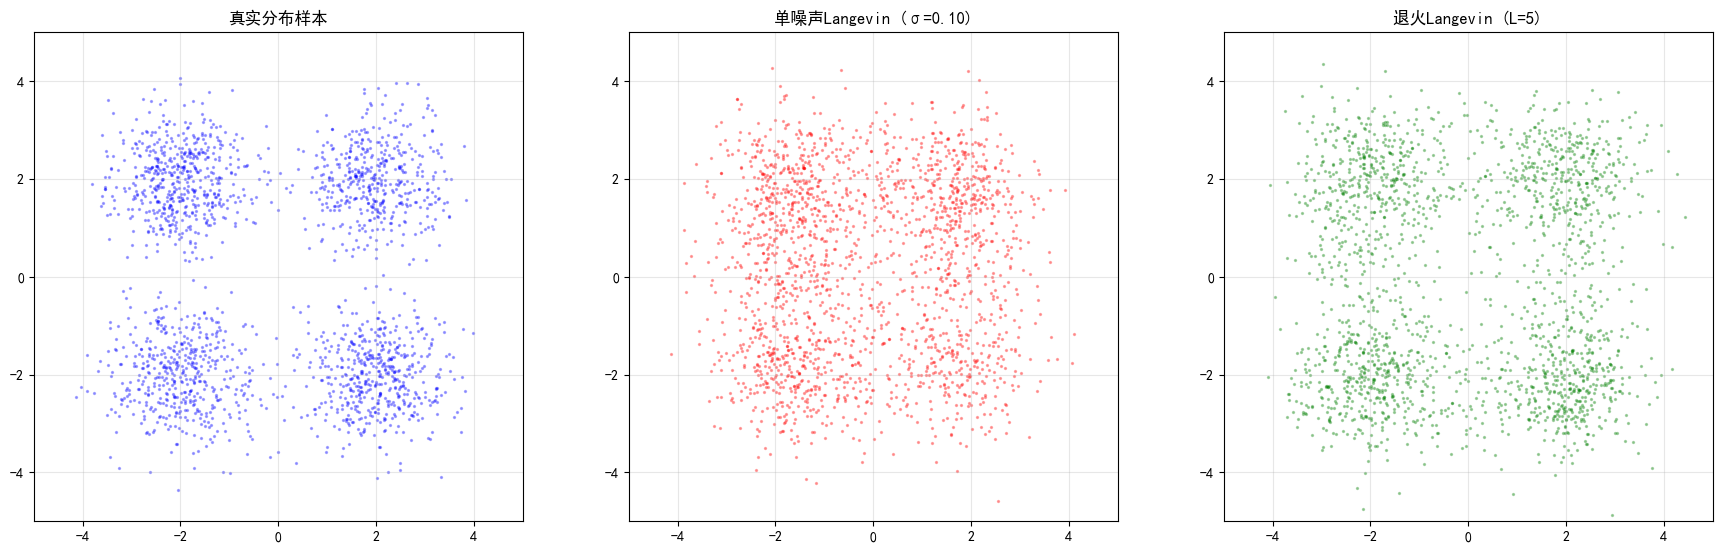

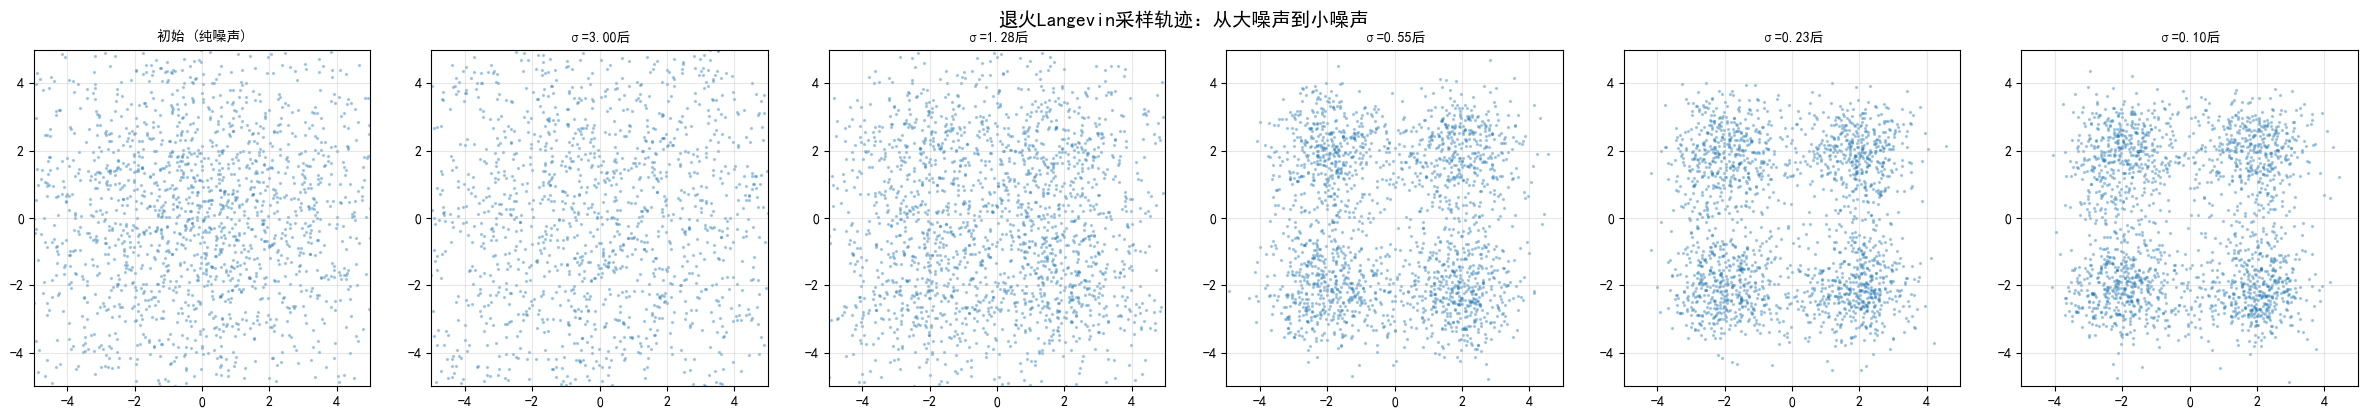


噪声调度设计原则验证

未加权DSM损失的相对量级 (1/σ²规律):
  σ_1=3.000: 1/σ² = 0.111
  σ_2=1.282: 1/σ² = 0.609
  σ_3=0.548: 1/σ² = 3.333
  σ_4=0.234: 1/σ² = 18.257
  σ_5=0.100: 1/σ² = 100.000

σ²加权后的损失量级 (应接近均匀):
  σ_1=3.000: σ²×(1/σ²) = 1.000 (理论上)
  σ_2=1.282: σ²×(1/σ²) = 1.000 (理论上)
  σ_3=0.548: σ²×(1/σ²) = 1.000 (理论上)
  σ_4=0.234: σ²×(1/σ²) = 1.000 (理论上)
  σ_5=0.100: σ²×(1/σ²) = 1.000 (理论上)

步长α_i = ε·σ_i²/σ_L²:
  σ_1=3.000: α_1 = 1.800000
  σ_2=1.282: α_2 = 0.328634
  σ_3=0.548: α_3 = 0.060000
  σ_4=0.234: α_4 = 0.010954
  σ_5=0.100: α_5 = 0.002000

实验6.4 总结
1. 单一噪声水平困境：
   - σ太小：低密度区域得分不准确，Langevin采样'迷路'
   - σ太大：得分只提供全局方向，模态细节丢失
2. NCSN多噪声水平策略：
   - 噪声调度σ₁=3.0→σ_L=0.1，几何级数排列
   - 大噪声'填满'低密度区域，小噪声保留分布细节
   - λ(σ)=σ²加权使各噪声水平贡献均匀
3. 退火Langevin采样：
   - 从大噪声到小噪声逐步采样，步长α_i∝σ_i²
   - 大噪声阶段：粗粒度调整，快速定位高密度区域
   - 小噪声阶段：细粒度调整，精确刻画模态细节
   - 退火ULA显著优于单噪声ULA，样本更接近真实分布
4. NCSN与扩散模型的桥梁：
   - 噪声调度↔时间步，退火Langevin↔逆向SDE
   - NCSN = 离散化扩散模型，第7章将展示连续化版本


In [1]:
"""
实验6.4 多尺度得分匹配与退火Langevin采样
对应章节：6.5（多尺度得分匹配：从单一噪声到噪声条件网络）
素材来源：
  - 03-smld.ipynb的NCSN训练和退火Langevin代码
  - Song & Ermon (2019) NCSN论文
  - ★ 原创设计：2D高斯混合上的多尺度得分匹配与退火采样演示

实验内容：
  步骤1：单一噪声水平的困境——低密度区域得分不准确
  步骤2：NCSN多噪声水平训练（2D高斯混合）
  步骤3：退火Langevin采样 vs 单噪声Langevin采样对比

运行前提：PyTorch CPU即可
"""

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'SimHei']
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
import torch
torch.manual_seed(42)

# 脚本所在目录（用于输出文件路径）
_SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()


# ============================================================
# 2D高斯混合分布（多模态，适合演示低密度区域问题）
# ============================================================
# 4个高斯分量，呈方形排列
mus = torch.tensor([[-2.0, -2.0], [-2.0, 2.0], [2.0, -2.0], [2.0, 2.0]])
covs = [torch.eye(2) * 0.5 for _ in range(4)]
weights = [0.25, 0.25, 0.25, 0.25]

def sample_gm2d(n):
    """从2D高斯混合采样"""
    samples = []
    for _ in range(n):
        k = np.random.choice(4, p=weights)
        x = mus[k] + torch.randn(2) * torch.sqrt(covs[k][0, 0])
        samples.append(x)
    return torch.stack(samples)

def gm2d_pdf(x1, x2):
    """2D高斯混合的密度值"""
    p = 0
    for k in range(4):
        mu = mus[k].numpy()
        v = covs[k][0, 0].item()
        p += weights[k] * np.exp(-0.5*((x1-mu[0])**2 + (x2-mu[1])**2)/v) / (2*np.pi*v)
    return p

def gm2d_score_np(x1, x2):
    """2D高斯混合的精确得分（NumPy版本）"""
    score1, score2 = 0, 0
    p_total = 0
    for k in range(4):
        mu = mus[k].numpy()
        v = covs[k][0, 0].item()
        pk = weights[k] * np.exp(-0.5*((x1-mu[0])**2 + (x2-mu[1])**2)/v) / (2*np.pi*v)
        score1 += pk * (-(x1-mu[0])/v)
        score2 += pk * (-(x2-mu[1])/v)
        p_total += pk
    return score1/p_total, score2/p_total

def gm2d_score_noisy_np(x1, x2, sigma):
    """噪声扰动后的得分 ∇log p_σ(x)"""
    v_total = 0.5 + sigma**2
    score1, score2 = 0, 0
    p_total = 0
    for k in range(4):
        mu = mus[k].numpy()
        pk = weights[k] * np.exp(-0.5*((x1-mu[0])**2 + (x2-mu[1])**2)/v_total) / (2*np.pi*v_total)
        score1 += pk * (-(x1-mu[0])/v_total)
        score2 += pk * (-(x2-mu[1])/v_total)
        p_total += pk
    return score1/p_total, score2/p_total


# ============================================================
# 步骤1：单一噪声水平的困境——低密度区域得分不准确
# ★ 原创设计：在2D高斯混合上展示不同σ的得分场覆盖范围
# ============================================================
print("=" * 60)
print("步骤1：单一噪声水平的困境")
print("=" * 60)

# 可视化不同噪声水平的得分场
fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
x_grid = np.linspace(-5, 5, 20)
y_grid = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x_grid, y_grid)

for idx, sigma in enumerate([0.1, 0.5, 1.0, 3.0]):
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    p_grid = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            s1, s2 = gm2d_score_noisy_np(X[i,j], Y[i,j], sigma)
            U[i,j] = s1
            V[i,j] = s2
            p_grid[i,j] = gm2d_pdf(X[i,j], Y[i,j])

    # 归一化箭头长度以便可视化
    mag = np.sqrt(U**2 + V**2)
    mag_max = np.percentile(mag, 95) + 1e-8
    U_norm = U / (mag + 0.1*mag_max)
    V_norm = V / (mag + 0.1*mag_max)

    axes1[idx].contourf(X, Y, p_grid, levels=20, cmap='Blues', alpha=0.4)
    axes1[idx].quiver(X, Y, U_norm, V_norm, mag, cmap='Reds', alpha=0.7, scale=30)
    axes1[idx].set_title(f'σ={sigma}')
    axes1[idx].set_xlim(-5, 5)
    axes1[idx].set_ylim(-5, 5)
    axes1[idx].set_aspect('equal')

axes1[0].set_ylabel('y')
fig1.suptitle('不同噪声水平的得分场（红色箭头=得分方向，蓝色=密度轮廓）', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(_SCRIPT_DIR, '步骤1_单一噪声水平困境.png'), dpi=150)
plt.show()

print("观察：")
print("  σ=0.1: 得分仅在模态附近非零，模态之间（低密度区域）几乎无方向指引")
print("  σ=0.5: 得分开始覆盖模态间区域")
print("  σ=1.0: 得分在整个区域都有方向指引，但模态细节开始模糊")
print("  σ=3.0: 得分全局覆盖良好，但无法区分不同模态——'只见森林不见树木'")


# ============================================================
# 步骤2：NCSN多噪声水平训练（2D高斯混合）
# ★ 原创设计：在2D上训练噪声条件得分网络
# ============================================================
print("\n" + "=" * 60)
print("步骤2：NCSN多噪声水平训练")
print("=" * 60)

# 噪声调度：几何级数
L = 5
sigma_1 = 3.0
sigma_L = 0.1
ratio = (sigma_1 / sigma_L) ** (1.0 / (L - 1))
sigmas = [sigma_1 * ratio ** (-i) for i in range(L)]
sigmas_t = torch.tensor(sigmas, dtype=torch.float32)
print(f"噪声调度 (L={L}): σ = {[f'{s:.3f}' for s in sigmas]}")
print(f"几何级数公比 r = {ratio:.3f}")

# 噪声条件得分网络（2D MLP，σ编码后注入）
class NCSNet2D(torch.nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        # σ编码：将σ映射到hidden维向量
        self.sigma_embed = torch.nn.Sequential(
            torch.nn.Linear(1, hidden),
            torch.nn.SiLU(),
        )
        # 主网络：x(2) + σ_embedding(hidden) → score(2)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2 + hidden, hidden),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden, 2),
        )

    def forward(self, x, sigma_idx):
        """x: (B,2), sigma_idx: (B,)"""
        s = sigmas_t[sigma_idx].unsqueeze(-1)  # (B,1)
        s_embed = self.sigma_embed(s)  # (B, hidden)
        inp = torch.cat([x, s_embed], dim=-1)  # (B, 2+hidden)
        return self.net(inp)

# 训练数据
N_train = 8000
x_train = sample_gm2d(N_train)

# NCSN训练
model = NCSNet2D()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"\n训练NCSN ({L}个噪声水平)...")
for epoch in range(1000):
    # 随机选择噪声水平
    sigma_idx = torch.randint(0, L, (N_train,))
    sigma_vals = sigmas_t[sigma_idx].unsqueeze(-1)  # (N,1)

    # 加噪声
    z = torch.randn(N_train, 2)
    x_noisy = x_train + sigma_vals * z

    # DSM目标: σ²/2 * ||s_θ(x̃,σ) + z/σ||²  (λ(σ)=σ²加权)
    pred = model(x_noisy, sigma_idx)
    target = -z / sigma_vals  # -z/σ
    loss_per_sample = 0.5 * sigma_vals.squeeze()**2 * torch.sum((pred - target)**2, dim=-1)
    loss = loss_per_sample.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f"  Epoch {epoch+1}: NCSN loss = {loss.item():.6f}")

print("NCSN训练完成！")


# ============================================================
# 步骤3：退火Langevin采样 vs 单噪声Langevin采样对比
# ★ 原创设计：2D上的采样对比，直观展示退火的优势
# ============================================================
print("\n" + "=" * 60)
print("步骤3：退火Langevin vs 单噪声Langevin采样对比")
print("=" * 60)

def langevin_sample(model, n_samples, T=200, epsilon=0.01, sigma_idx=0):
    """单噪声水平的Langevin采样"""
    x = torch.randn(n_samples, 2) * sigmas_t[sigma_idx]
    for t in range(T):
        idx = torch.full((n_samples,), sigma_idx, dtype=torch.long)
        with torch.no_grad():
            score = model(x, idx)
        x = x + epsilon/2 * score + np.sqrt(epsilon) * torch.randn(n_samples, 2)
    return x

def annealed_langevin_sample(model, n_samples, T_per_level=50, epsilon=2e-3):
    """退火Langevin采样（参考03-smld.ipynb的run_inference）"""
    x = torch.randn(n_samples, 2) * sigmas_t[0]
    trajectories = [x.clone().numpy()]

    for i in range(L):
        # 步长 α_i = ε · σ_i² / σ_L²
        alpha_i = epsilon * (sigmas_t[i] / sigmas_t[-1])**2
        for t in range(T_per_level):
            idx = torch.full((n_samples,), i, dtype=torch.long)
            with torch.no_grad():
                score = model(x, idx)
            x = x + alpha_i/2 * score + torch.sqrt(alpha_i) * torch.randn(n_samples, 2)
        trajectories.append(x.clone().numpy())

    return x, trajectories

# 单噪声Langevin（小噪声）
n_samples = 2000
print(f"\n运行单噪声Langevin (σ={sigmas[-1]:.2f}, T=500)...")
samples_single = langevin_sample(model, n_samples, T=500, epsilon=0.005, sigma_idx=L-1)

# 退火Langevin
print(f"运行退火Langevin (L={L}, T_per_level=100)...")
samples_annealed, trajectories = annealed_langevin_sample(model, n_samples, T_per_level=100, epsilon=2e-3)

# 真实样本
samples_true = sample_gm2d(n_samples).numpy()

# 评估采样质量（各象限的样本比例）
def quadrant_stats(samples_np):
    q1 = np.mean((samples_np[:,0] > 0) & (samples_np[:,1] > 0))
    q2 = np.mean((samples_np[:,0] < 0) & (samples_np[:,1] > 0))
    q3 = np.mean((samples_np[:,0] < 0) & (samples_np[:,1] < 0))
    q4 = np.mean((samples_np[:,0] > 0) & (samples_np[:,1] < 0))
    return [q1, q2, q3, q4]

true_stats = quadrant_stats(samples_true)
single_stats = quadrant_stats(samples_single.numpy())
annealed_stats = quadrant_stats(samples_annealed.numpy())

print(f"\n各象限样本比例:")
print(f"{'象限':>6s} | {'真实':>8s} | {'单噪声ULA':>10s} | {'退火ULA':>8s}")
print("-" * 42)
for i, name in enumerate(['Q1(++)', 'Q2(-+)', 'Q3(--)', 'Q4(+-)']):
    print(f"{name:>6s} | {true_stats[i]:8.3f} | {single_stats[i]:10.3f} | {annealed_stats[i]:8.3f}")


# ============================================================
# 可视化
# ============================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5.5))

# 子图1：真实分布
axes2[0].scatter(samples_true[:,0], samples_true[:,1], s=2, alpha=0.3, c='blue')
axes2[0].set_title('真实分布样本')
axes2[0].set_xlim(-5, 5)
axes2[0].set_ylim(-5, 5)
axes2[0].set_aspect('equal')
axes2[0].grid(alpha=0.3)

# 子图2：单噪声Langevin
axes2[1].scatter(samples_single.numpy()[:,0], samples_single.numpy()[:,1], s=2, alpha=0.3, c='red')
axes2[1].set_title(f'单噪声Langevin (σ={sigmas[-1]:.2f})')
axes2[1].set_xlim(-5, 5)
axes2[1].set_ylim(-5, 5)
axes2[1].set_aspect('equal')
axes2[1].grid(alpha=0.3)

# 子图3：退火Langevin
axes2[2].scatter(samples_annealed.numpy()[:,0], samples_annealed.numpy()[:,1], s=2, alpha=0.3, c='green')
axes2[2].set_title(f'退火Langevin (L={L})')
axes2[2].set_xlim(-5, 5)
axes2[2].set_ylim(-5, 5)
axes2[2].set_aspect('equal')
axes2[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(_SCRIPT_DIR, '步骤2_退火Langevin对比.png'), dpi=150)
plt.show()

# 退火Langevin的逐步演化
fig3, axes3 = plt.subplots(1, L+1, figsize=(4*(L+1), 4))
for i, traj in enumerate(trajectories):
    if i == 0:
        title = '初始 (纯噪声)'
    else:
        title = f'σ={sigmas[i-1]:.2f}后'
    axes3[i].scatter(traj[:,0], traj[:,1], s=2, alpha=0.3)
    axes3[i].set_title(title, fontsize=10)
    axes3[i].set_xlim(-5, 5)
    axes3[i].set_ylim(-5, 5)
    axes3[i].set_aspect('equal')
    axes3[i].grid(alpha=0.3)

fig3.suptitle('退火Langevin采样轨迹：从大噪声到小噪声', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(_SCRIPT_DIR, '步骤3_退火轨迹演化.png'), dpi=150)
plt.show()


# ============================================================
# 噪声调度设计原则验证
# ============================================================
print("\n" + "=" * 60)
print("噪声调度设计原则验证")
print("=" * 60)

# 验证λ(σ)=σ²加权使各噪声水平损失量级均匀
print("\n未加权DSM损失的相对量级 (1/σ²规律):")
for i, s in enumerate(sigmas):
    print(f"  σ_{i+1}={s:.3f}: 1/σ² = {1/s**2:.3f}")

print("\nσ²加权后的损失量级 (应接近均匀):")
for i, s in enumerate(sigmas):
    print(f"  σ_{i+1}={s:.3f}: σ²×(1/σ²) = 1.000 (理论上)")

print("\n步长α_i = ε·σ_i²/σ_L²:")
epsilon = 2e-3
for i, s in enumerate(sigmas):
    alpha_i = epsilon * (s / sigmas[-1])**2
    print(f"  σ_{i+1}={s:.3f}: α_{i+1} = {alpha_i:.6f}")


# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验6.4 总结")
print("=" * 60)
print("1. 单一噪声水平困境：")
print("   - σ太小：低密度区域得分不准确，Langevin采样'迷路'")
print("   - σ太大：得分只提供全局方向，模态细节丢失")
print("2. NCSN多噪声水平策略：")
print(f"   - 噪声调度σ₁={sigmas[0]:.1f}→σ_L={sigmas[-1]:.1f}，几何级数排列")
print("   - 大噪声'填满'低密度区域，小噪声保留分布细节")
print("   - λ(σ)=σ²加权使各噪声水平贡献均匀")
print("3. 退火Langevin采样：")
print("   - 从大噪声到小噪声逐步采样，步长α_i∝σ_i²")
print("   - 大噪声阶段：粗粒度调整，快速定位高密度区域")
print("   - 小噪声阶段：细粒度调整，精确刻画模态细节")
print("   - 退火ULA显著优于单噪声ULA，样本更接近真实分布")
print("4. NCSN与扩散模型的桥梁：")
print("   - 噪声调度↔时间步，退火Langevin↔逆向SDE")
print("   - NCSN = 离散化扩散模型，第7章将展示连续化版本")
